# Category & Promo Analytics для онлайн-ритейла

## Анализ продаж, промо-доли, маржинальности и ABC-сегментации по категориям и подкатегориям

### Бизнес-цель

Оценить структуру продаж по товарным категориям онлайн-ритейла, выявить ключевые драйверы объёма и выручки, оценить влияние промо на категорию «Сыры» и маржинальность ассортимента для приоритизации категорийного менеджмента.

### Аналитические задачи 
1. Определить категорию с наибольшим объёмом продаж.
2. Описать распределение продаж внутри категорий по подкатегориям.
3. Рассчитать средний чек за 13.01.2022.
4. Оценить долю промо-продаж в категории «Сыры».
5. Посчитать маржу по категориям (руб. и %).
6. Провести ABC-анализ подкатегорий по объёму и по выручке, сформировать итоговую матрицу сегментов.

### Ограничения и допущения 
- Анализ по штукам и выручке — только для товаров, присутствующих в справочнике products.
- Промо определяется как price ≠ regular_price.
- ABC — на уровне subcategory (подкатегории).
- Период данных: 13.01.2022 (один день).

### Описание данных

Таблица `products`:
- `product_id` — id товара
- `category` — товарная категория (в исходнике: `level1`)
- `subcategory` — подкатегория (в исходнике: `level2`)
- `name` — наименование товара

Таблица `orders`:
- `order_id` — номер чека
- `accepted_at` — дата и время чека
- `product_id` — id товара
- `quantity` — кол-во товара в чеке
- `regular_price` — регулярная цена
- `price` — текущая цена
- `cost_price` — закупочная цена

In [283]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [284]:
orders = pd.read_excel('data/orders.xlsx')
products = pd.read_excel('data/products.xlsx')

products = products.rename(columns={
    'level1': 'category',
    'level2': 'subcategory',
})

### Первичный обзор данных

Смотрим каждую таблицу отдельно: структуру, пропуски и ключевые проверки

#### Таблица `orders`

In [285]:
orders.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [286]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3323 non-null   int64         
 1   accepted_at    3323 non-null   datetime64[us]
 2   product_id     3323 non-null   int64         
 3   quantity       3323 non-null   int64         
 4   regular_price  3323 non-null   int64         
 5   price          3323 non-null   int64         
 6   cost_price     3323 non-null   int64         
dtypes: datetime64[us](1), int64(6)
memory usage: 181.9 KB


In [287]:
orders.describe()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
count,3.323000e+03,3323,3323.000000,3323.00000,3323.000000,3323.000000,3323.000000
mean,1.517529e+09,2022-01-13 16:02:37.557628,22961.379175,1.23533,139.828167,130.645501,81.106229
min,1.517207e+09,2022-01-13 08:00:30,23.000000,1.00000,11.000000,4.000000,7.000000
25%,1.517454e+09,2022-01-13 12:50:33,6008.000000,1.00000,77.000000,72.000000,42.000000
50%,1.517524e+09,2022-01-13 16:26:22,12114.000000,1.00000,117.000000,109.000000,67.000000
75%,1.517605e+09,2022-01-13 19:22:00,30321.500000,1.00000,179.000000,165.000000,101.000000
max,1.517855e+09,2022-01-13 22:58:29,120497.000000,12.00000,1797.000000,1797.000000,808.000000
std,1.029182e+05,NaN,25476.196162,0.78861,104.195194,96.328751,61.505484


In [288]:
orders['order_id'].nunique()

544

**Вывод `orders`:** 
- Таблица без пропусков
- Данные представленны за один день `13.01.2022`
- Кол-во уникальных заказов - 544
- `quantity` и `price` в допустимых значениях (min ≥ 1, отрицательных значений нет)

#### Таблица `products`

In [289]:
products.head()

,product_id,category,subcategory,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


In [290]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 40152 entries, 0 to 40151
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   product_id   40152 non-null  int64
 1   category     40152 non-null  str  
 2   subcategory  40152 non-null  str  
 3   name         39940 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.2 MB


In [291]:
print(f'Уникальных категорий: {products['category'].nunique()}')
print(f'Уникальных податегорий: {products['subcategory'].nunique()}')
print(f'Пропущенных значений в колонке "name": {products['name'].isna().sum()}')

Уникальных категорий: 33
Уникальных податегорий: 168
Пропущенных значений в колонке "name": 212


**Вывод `products`:**
- Дата фрейм пригоден для категорийного анализа
- Пропуски есть только в `name` - на расчёты по категориям не повлияют
- Дубликатов `product_id` нет.

### Подготовка данных для анализа

In [292]:
order_items = orders.merge(products, on='product_id', how='inner')

In [293]:
order_items.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,category,subcategory,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат


In [294]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 3018 entries, 0 to 3017
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3018 non-null   int64         
 1   accepted_at    3018 non-null   datetime64[us]
 2   product_id     3018 non-null   int64         
 3   quantity       3018 non-null   int64         
 4   regular_price  3018 non-null   int64         
 5   price          3018 non-null   int64         
 6   cost_price     3018 non-null   int64         
 7   category       3018 non-null   str           
 8   subcategory    3018 non-null   str           
 9   name           3010 non-null   str           
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 235.9 KB


Настройки для графиков

In [295]:
plt.rcParams.update({
    "figure.figsize": (16, 8),      
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.grid": True,           
    "grid.alpha": 0.3,
})

Метод для построения графиков

In [296]:
def plot_chart(
    df,
    kind="bar",
    x=None,
    y=None,
    title="",
    xlabel="",
    ylabel="",
    legend=False,
    **kwargs,          # color, rot, stacked
):
    ax = df.plot(
        kind=kind,
        x=x,
        y=y,
        legend=legend,
        **kwargs,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

### 1. Категории товаров с наибольшим объёмом продаж

In [297]:
sales_by_category_df = order_items.groupby('category', as_index=False) \
                    .agg(units_category=('quantity', 'sum')) \
                    .sort_values('units_category', ascending=False)

In [298]:
sales_by_category_df.head()


,category,units_category
1,Безалкогольные напитки,534
11,Молочная продукция,483
19,Свежие овощи,262
10,Кулинария,250
0,Бакалея,239


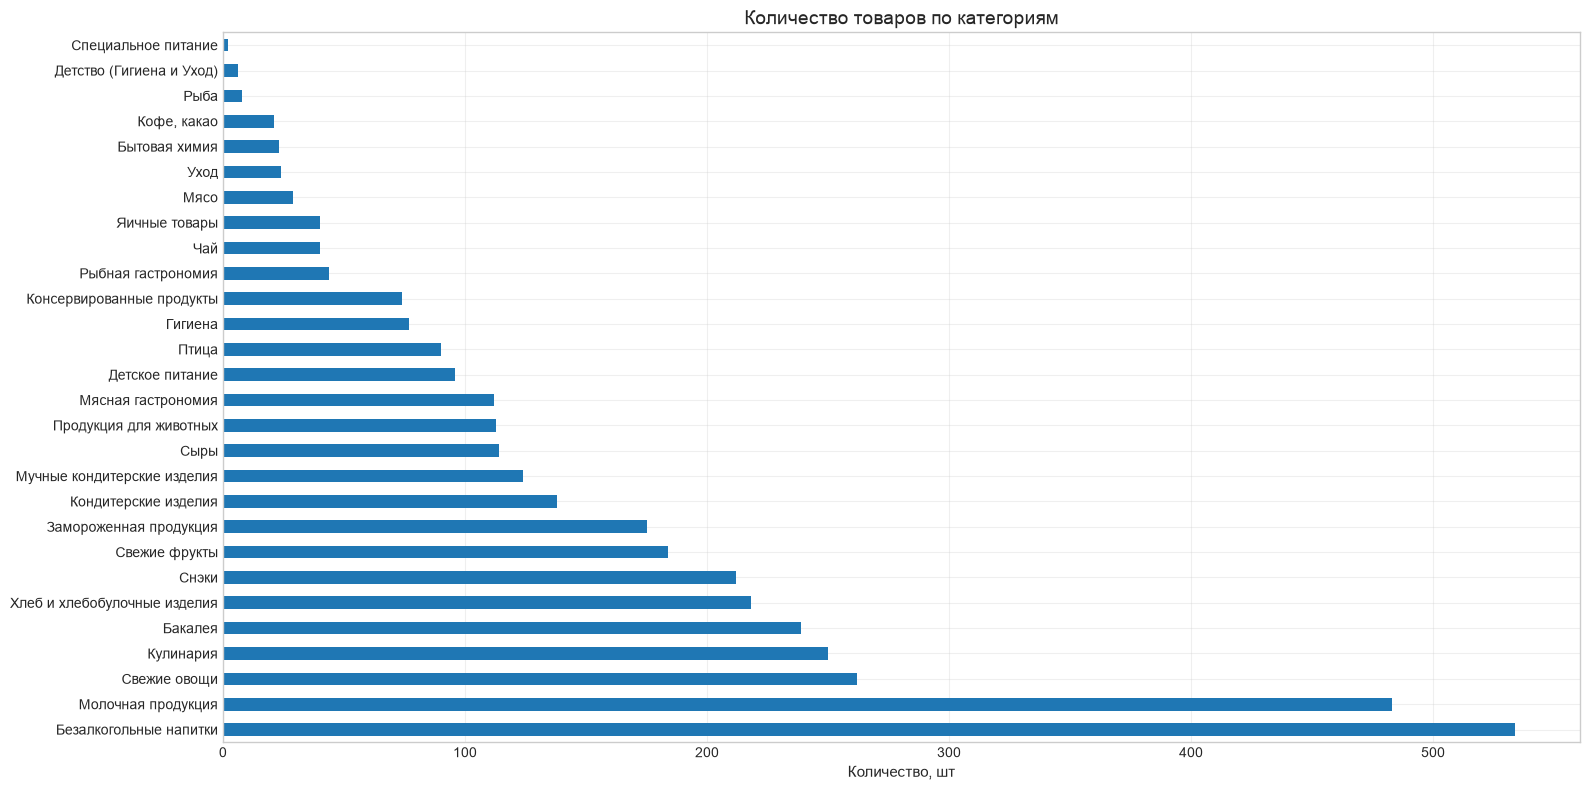

In [299]:
plot_chart(
  sales_by_category_df,
  kind='barh',
  x="category", 
  y="units_category",
  title="Количество товаров по категориям",
  xlabel="Количество, шт"
)

In [300]:
all_categories = set(products["category"])
sold_categories = set(order_items["category"])
no_sales = sorted(all_categories - sold_categories)
no_sales

['Не распределено',
 'Парфюмерия и декоративная косметика',
 'Промышленные товары',
 'Рынок',
 'Табачные изделия']

#### Вывод:

- Продажи сильно сконцентрированы в двух категориях: `безалкогольные напитки` и `молочная продукция`. Две первые категории по объёму почти равны следующим пяти–шести вместе.

- Дальше идут повседневные продукты, которые покупают часто: `овощи`, `кулинария`, `бакалея`, `хлеб`, `снэки`, `фрукты`. Вместе с топом это основной набор категорий, на который приходится большая часть продаж.

- Внизу списка — `рыба`, `детская гигиена` и `спецпитание`: продаж очень мало. Причины могут быть разные - мало товаров в наличии или просто низкий спрос. Это стоит проверить отдельно.

- За день покупки были в `28` из `33` категорий. Без продаж: `Не распределено`, `Парфюмерия и декоративная косметика`, `Промышленные товары`, `Рынок`, `Табачные изделия`. Это не обязательно «мёртвые» категории — за один день их могли просто не купить.

- **Что делать**: продвигать топовые товары и следить что бы он был в наличии. По слабым не спешить с решениями, сначала нужно понять, почему так мало продаж, и только потом принимать решение.

### 2. Распределение продаж внутри категорий по подкатегориям


Для начала вычислим какое количество товаров продовалось в каждой подкатегори


In [301]:
subcategory_sales_df = order_items.groupby(['category', 'subcategory'], as_index=False) \
                      .agg(units_subcategory = ('quantity', 'sum'))                     


Присоединим к таблице `subcategory_sales_df` общий объём по категории из `sales_by_category_df`, чтобы потом считать долю внутри category.


In [302]:
subcategory_sales_df = subcategory_sales_df.merge(sales_by_category_df, on='category', how='inner') 


Добавим `share_pct`, долю продаж подкатегории внутри своей категории, в процентах.


In [310]:
subcategory_sales_df['share_pct'] = (subcategory_sales_df['units_subcategory'] / subcategory_sales_df['units_category'] * 100) \
                                    .round(2)


In [ ]:
subcategory_sales_df = subcategory_sales_df
subcategory_sales_df


,category,subcategory,units_subcategory,units_category,share_pct
10,Бакалея,Сухие блюда быстрого приготовления,38,239,15.90
3,Бакалея,"Крупы, бобовые",30,239,12.55
1,Бакалея,Зерновые для завтраков,24,239,10.04
4,Бакалея,Макаронные изделия,24,239,10.04
9,Бакалея,Соусы,24,239,10.04
...,...,...,...,...,...
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218,218,100.00
98,Чай,Черный чай,26,40,65.00
96,Чай,Зеленый чай,7,40,17.50
97,Чай,Чайные напитки,7,40,17.50


#### Вывод

### 3. Рассчитать средний чек за 13.01.2022

In [326]:
revenue_by_order_df = orders.copy()
revenue_by_order_df['line_revenue'] = revenue_by_order_df['quantity'] * revenue_by_order_df['price']

In [329]:
order_totals_df = revenue_by_order_df.groupby('order_id', as_index=False) \
                      .agg(order_total=('line_revenue', 'sum'))

order_totals_df.head()

,order_id,order_total
0,1517207363,795
1,1517288545,364
2,1517293568,1715
3,1517302077,2096
4,1517305540,342


In [330]:
average_check = order_totals_df['order_total'].mean().round(2)
average_check

np.float64(915.64)

#### Вывод
Средний чек за 13.01.2022 — `915.64` рублей

### 4. Оценить долю промо-продаж в категории «Сыры».

Сначала выделим все продажи категории `Сыры` и посчитаем общий объём продаж по штукам и по выручке.

In [368]:
cheese_items_df = order_items.query("category == 'Сыры'")
total_units = cheese_items_df['quantity'].sum()
total_revenue = (cheese_items_df['quantity'] * cheese_items_df['price']).sum()

Затем отберём только промо-продажи в категории `Сыры`. Промо определяем как `price` < `regular_price`, то есть продажа по цене ниже регулярной.

In [369]:
cheese_promo_items_df = cheese_items_df.query("price < regular_price")
promo_units = cheese_promo_items_df['quantity'].sum()
promo_revenue = (cheese_promo_items_df['quantity'] * cheese_promo_items_df['price']).sum()

Рассчитаем долю промо-продаж в категории `Сыры`, отдельно по штукам и по выручке.

In [374]:
promo_share_units_pct = (promo_units / total_units * 100).round(2)
promo_share_revenue_pct = (promo_revenue / total_revenue * 100).round(2)

In [375]:
print(f'Вклад по штукам: {promo_share_units_pct}')
print(f'Вклад по выручке: {promo_share_revenue_pct}')

Вклад по штукам: 30.7
Вклад по выручке: 23.19


Для наглядной интерпретации результата визуализируем долю промо-продаж в категории Сыры с помощью двух круговых диаграмм.

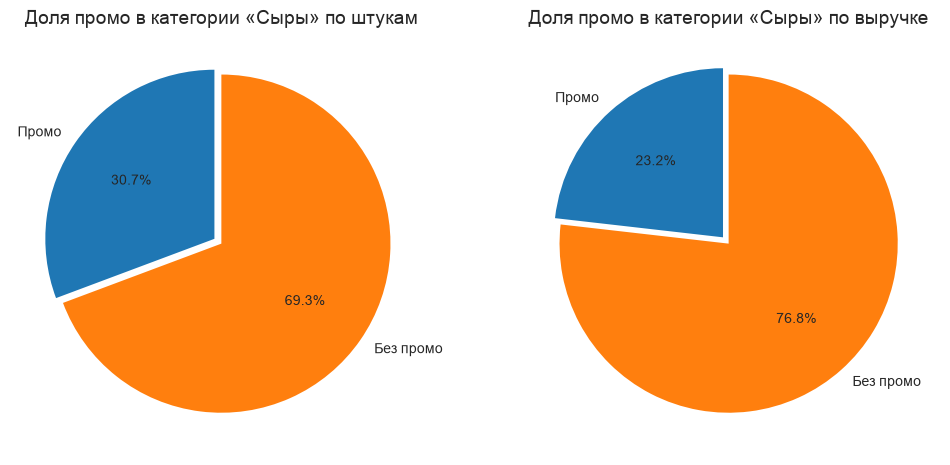

In [392]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(
    [promo_share_units_pct, 100 - promo_share_units_pct],
    labels=['Промо', 'Без промо'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title('Доля промо в категории «Сыры» по штукам')

axes[1].pie(
    [promo_share_revenue_pct, 100 - promo_share_revenue_pct],
    labels=['Промо', 'Без промо'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[1].set_title('Доля промо в категории «Сыры» по выручке')

plt.show()

#### Вывод
В категории Сыры доля промо-продаж составила `30.7%` по штукам и `23.19%` по выручке. Промо заметно поддерживает объём продаж в категории, однако его вклад в выручку ниже, чем в количество проданных единиц. Это может означать, что скидки чаще применялись к более дешёвым позициям или к товарам с меньшим вкладом в денежный оборот категории.